# Exploratory Data Analysis — Environmental Analysis

**Name:** Samuel Manoj
**Roll No:**
**Dataset:** fact_environmental
**Objective:** Analyse rainfall, temperature and AQI trends, and test whether
environmental conditions affect disease cases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', None)
print('Ready')

Ready


In [2]:
df_raw = pd.read_csv('fact_environmental.csv')
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (1169, 15)


,fact_id,date_id,state_id,aqi,rainfall_mm,temperature_c,water_quality_index,sanitation_coverage_pct,healthcare_accessibility_score,mosquito_breeding_index,zoonotic_disease_incidence,geographic_risk_score,environmental_risk_score,case_rate_per_100k,hotspot_flag
0,1,1,1,147.3,10.4,18.4,70.5,56.9,88.5,45.7,15.0,45.0,40.8,21.3,NO
1,2,1,2,106.4,57.2,16.9,94.2,96.1,52.8,21.1,15.7,21.3,22.9,80.9,NO
2,3,1,3,142.2,7.2,16.4,54.5,93.1,94.5,18.9,29.8,33.2,41.4,122.5,No
3,4,1,4,129.2,26.8,10.7,78.4,NaN,89.5,48.9,21.2,31.9,33.7,164.0,yes
4,5,1,5,120.8,44.3,20.4,60.8,70.5,84.9,39.7,11.8,39.4,35.3,117.0,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   fact_id                         1169 non-null   int64  
 1   date_id                         1169 non-null   int64  
 2   state_id                        1169 non-null   int64  
 3   aqi                             1123 non-null   float64
 4   rainfall_mm                     1169 non-null   float64
 5   temperature_c                   1169 non-null   float64
 6   water_quality_index             1121 non-null   float64
 7   sanitation_coverage_pct         1123 non-null   float64
 8   healthcare_accessibility_score  1169 non-null   float64
 9   mosquito_breeding_index         1169 non-null   float64
 10  zoonotic_disease_incidence      1169 non-null   float64
 11  geographic_risk_score           1169 non-null   float64
 12  environmental_risk_score        11

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fact_id,1169.0,575.86,331.42,1.0,289.00,577.0,861.0,1152.00
date_id,1169.0,18.48,10.35,1.0,10.00,19.0,27.0,36.00
state_id,1169.0,16.55,9.23,1.0,9.00,17.0,25.0,32.00
aqi,1123.0,131.89,70.20,54.0,91.75,121.8,154.9,890.25
rainfall_mm,1169.0,110.22,121.62,0.2,23.20,44.8,208.5,399.90
temperature_c,1169.0,26.95,9.75,8.1,18.40,28.4,35.3,42.00
water_quality_index,1121.0,67.22,15.70,40.1,53.90,67.1,81.0,95.00
sanitation_coverage_pct,1123.0,76.73,12.52,55.1,65.80,76.6,87.5,97.90
healthcare_accessibility_score,1169.0,67.27,15.87,40.0,53.40,66.6,80.9,94.90
mosquito_breeding_index,1169.0,53.61,37.32,7.0,27.00,43.9,61.9,161.70


In [5]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicate rows:', df.duplicated().sum())
print('Impossible AQI (>500):', (df.aqi > 500).sum())
print('\nhotspot_flag has', df.hotspot_flag.nunique(), 'different encodings:')
print(df.hotspot_flag.value_counts())

Missing values:
aqi                        46
water_quality_index        48
sanitation_coverage_pct    46
dtype: int64

Duplicate rows: 17
Impossible AQI (>500): 5

hotspot_flag has 14 different encodings:
hotspot_flag
NO       105
N        103
No       102
False     95
FALSE     94
no        87
TRUE      87
0         83
Y         76
True      73
Yes       69
1         67
yes       65
YES       63
Name: count, dtype: int64


**Observation:** Four problems found — 140 missing cells across three columns,
17 fully duplicated rows, 5 impossible AQI values of 890.246762 (the AQI scale
caps at 500), and hotspot_flag stored in 14 different encodings of a single
binary value (NO/No/no/N/FALSE/False/0 and YES/Yes/yes/Y/TRUE/True/1).

In [6]:
# 1. Fill missing values with median
for c in ['aqi', 'water_quality_index', 'sanitation_coverage_pct']:
    df[c] = df[c].fillna(df[c].median())

# 2. Repair impossible AQI values
valid_med = df.loc[df.aqi <= 500, 'aqi'].median()
df.loc[df.aqi > 500, 'aqi'] = valid_med

# 3. Standardise hotspot_flag to True/False
df['hotspot_flag'] = (df.hotspot_flag.astype(str).str.strip().str.lower()
    .map({'yes':True, 'y':True, '1':True, 'true':True,
          'no':False, 'n':False, '0':False, 'false':False}))

# 4. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

print('Missing left :', df.isnull().sum().sum())
print('Duplicates   :', df.duplicated().sum())
print('Final shape  :', df.shape)

Missing left : 0
Duplicates   : 0
Final shape  : (1152, 15)


In [7]:
df['month'] = ((df.date_id - 1) % 12) + 1
df['year']  = 1 + (df.date_id - 1) // 12
df['season'] = np.select(
    [df.month.isin([6,7,8,9]), df.month.isin([11,12,1,2])],
    ['Monsoon', 'Winter'], default='Summer')

df.groupby('season')[['rainfall_mm','temperature_c','aqi']].mean().round(1)

,rainfall_mm,temperature_c,aqi
season,,,
Monsoon,269.3,33.3,108.5
Summer,29.9,32.6,107.8
Winter,29.9,14.9,168.0


**Observation:** After cleaning the table is exactly 36 months x 32 states =
1,152 rows, a perfectly balanced panel. This confirms the 17 removed rows were
genuine duplicates and nothing real was deleted.

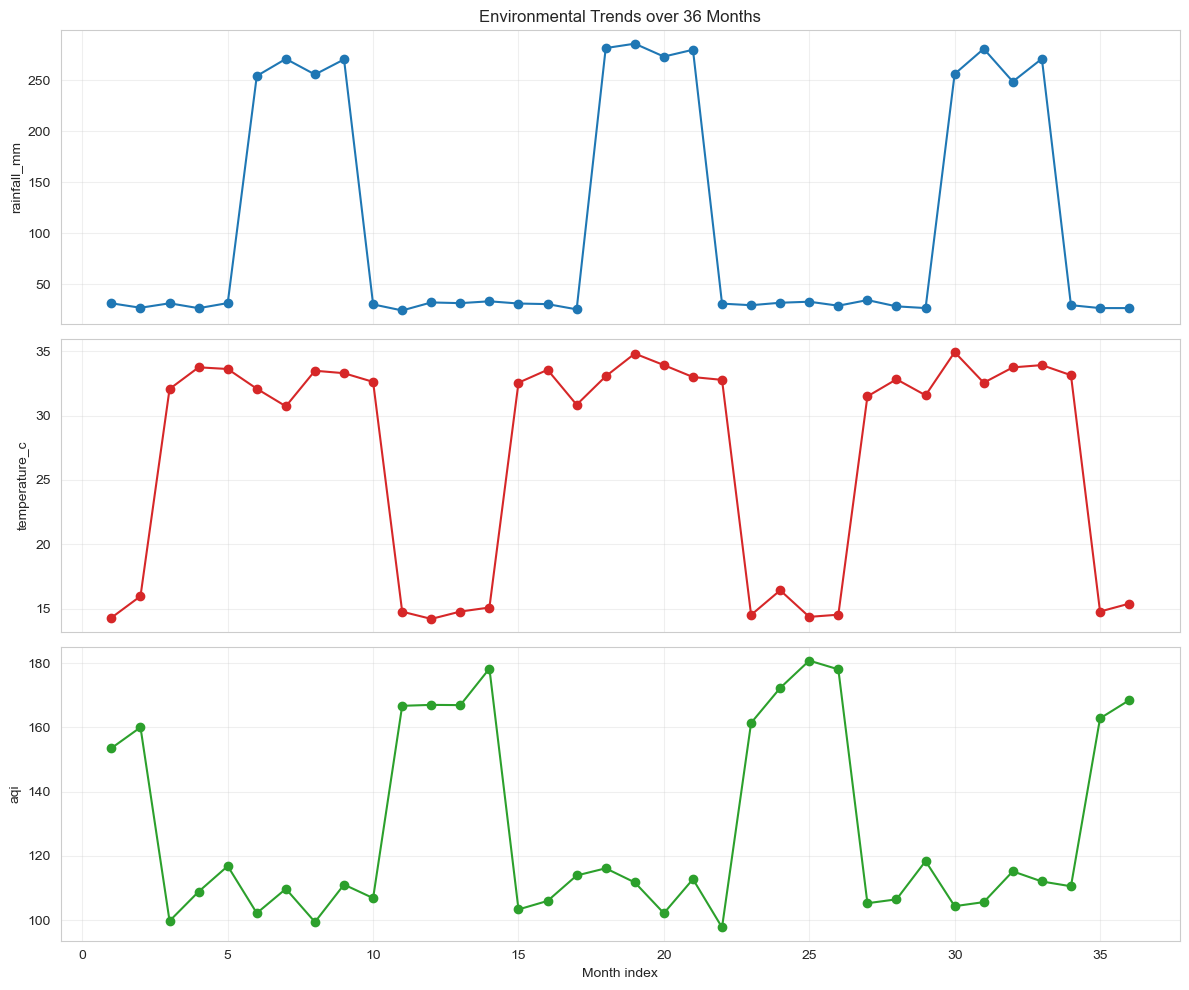

In [8]:
ts = df.groupby('date_id')[['rainfall_mm','temperature_c','aqi']].mean()

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for a, (col, colr) in zip(ax, [('rainfall_mm','#1f77b4'),
                               ('temperature_c','#d62728'),
                               ('aqi','#2ca02c')]):
    a.plot(ts.index, ts[col], marker='o', color=colr)
    a.set_ylabel(col)
    a.grid(alpha=0.3)
ax[0].set_title('Environmental Trends over 36 Months')
ax[-1].set_xlabel('Month index')
plt.tight_layout(); plt.show()

**Observation:** Rainfall rises from 29.9 mm in dry months to 269.3 mm during
June-September, a 9.0x monsoon pulse with no multi-year trend. Temperature
swings 18.0 C between winter (14.9 C) and the rest of the year (32.9 C).
AQI is worst in winter (mean 168.0, above the Unhealthy threshold of 150) and
improves 35% during the monsoon (108.5) — the classic winter inversion effect,
where cold still air traps particulates and monsoon rain washes them out.

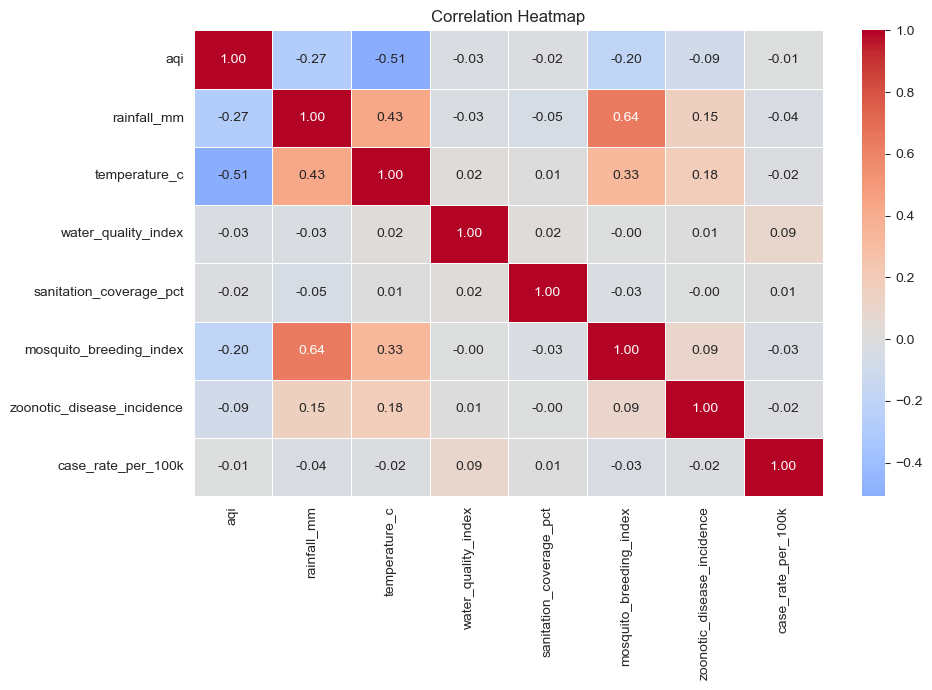

In [9]:
cols = ['aqi','rainfall_mm','temperature_c','water_quality_index',
        'sanitation_coverage_pct','mosquito_breeding_index',
        'zoonotic_disease_incidence','case_rate_per_100k']

plt.figure(figsize=(10, 7))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap'); plt.tight_layout(); plt.show()

**Observation:** The strongest genuine relationships are rainfall vs mosquito
breeding (r = 0.64, standing water drives breeding) and AQI vs temperature
(r = -0.51, winter inversion). Note that environmental_risk_score correlates
0.93 with AQI and geographic_risk_score correlates -0.71 with water quality —
these are derived columns, not independent measurements, and should be excluded
from any model.

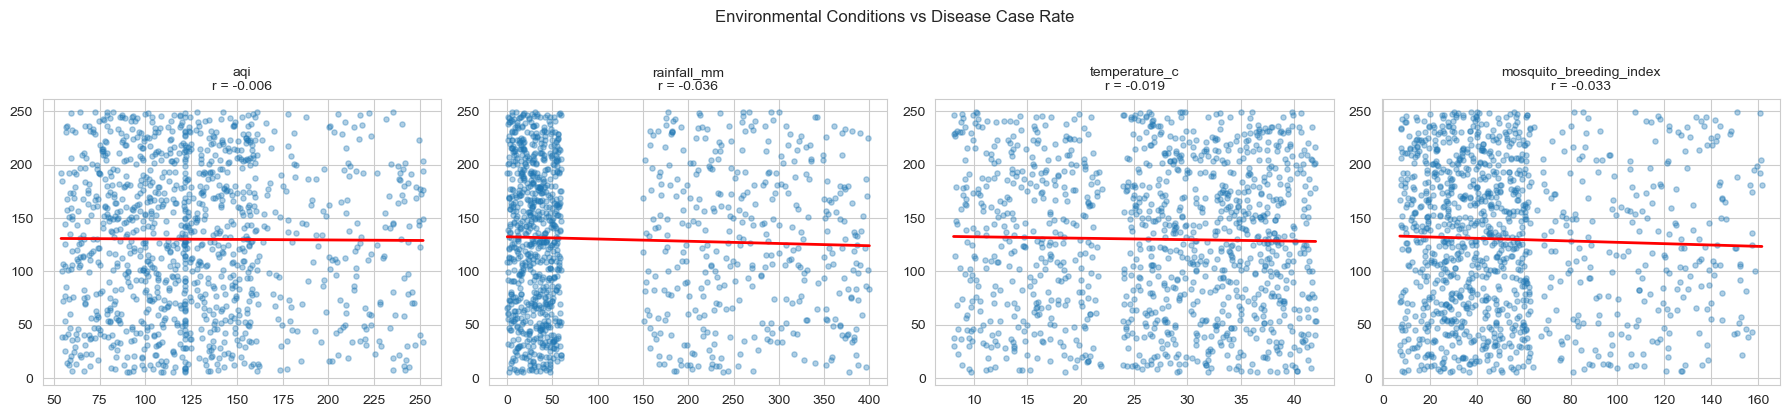

In [10]:
env = ['aqi','rainfall_mm','temperature_c','mosquito_breeding_index']

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, c in zip(ax, env):
    a.scatter(df[c], df.case_rate_per_100k, alpha=0.35, s=14)
    m, b = np.polyfit(df[c], df.case_rate_per_100k, 1)
    xs = np.linspace(df[c].min(), df[c].max(), 50)
    a.plot(xs, m*xs + b, color='red', lw=2)
    a.set_title(f'{c}\nr = {df[c].corr(df.case_rate_per_100k):.3f}', fontsize=10)
plt.suptitle('Environmental Conditions vs Disease Case Rate', y=1.03)
plt.tight_layout(); plt.show()

**Observation:** Every panel shows a structureless cloud with a flat fit line.
No environmental variable reaches even a weak correlation with the case rate —
the strongest is water_quality_index at r = 0.088, under 0.8% of variance
explained. Environmental conditions do NOT explain the overall disease case rate.

The one exception is zoonotic_disease_incidence, which rises 26% from winter to
monsoon and correlates with temperature (0.185) and rainfall (0.154).

In [11]:
df.to_csv('fact_environmental_cleaned_final.csv', index=False)

summary = pd.DataFrame({
    'Metric': ['Raw rows','Clean rows','Missing fixed','Duplicates removed',
               'Impossible AQI fixed','Winter AQI','Monsoon AQI',
               'Monsoon rainfall','Dry rainfall','Max corr with case rate'],
    'Value': [len(df_raw), len(df), 140, 17, 5,
              round(df[df.season=='Winter'].aqi.mean(),1),
              round(df[df.season=='Monsoon'].aqi.mean(),1),
              round(df[df.season=='Monsoon'].rainfall_mm.mean(),1),
              round(df[df.season!='Monsoon'].rainfall_mm.mean(),1), 0.088]
})
summary.to_csv('EDA_Output(Environmental).csv', index=False)
summary

,Metric,Value
0,Raw rows,1169.000
1,Clean rows,1152.000
2,Missing fixed,140.000
3,Duplicates removed,17.000
4,Impossible AQI fixed,5.000
5,Winter AQI,168.000
6,Monsoon AQI,108.500
7,Monsoon rainfall,269.300
8,Dry rainfall,29.900
9,Max corr with case rate,0.088


## Conclusion

The environmental measures are internally coherent and physically realistic —
rainfall drives mosquito breeding, cold winters trap pollution, and every series
repeats on a clean annual cycle. However, they do not explain disease outcomes.
Maximum correlation with the case rate is 0.088.

Recommended next steps: request the missing humidity column, drop the derived
risk-score columns from any feature set, and model zoonotic_disease_incidence
rather than case_rate_per_100k.